## GPT-2 From Scratch

### 3.1 Coding an LLM architecture (GPT-2 Placeholder Architecture (GPT Backbone))

In [1]:
from importlib.metadata import version

print("matplotlib version:", version("matplotlib"))
print("torch version:", version("torch"))
print("tiktoken version:", version("tiktoken"))

matplotlib version: 3.10.6
torch version: 2.9.1
tiktoken version: 0.12.0


In [2]:
GPT_CONFIG_124M = {
    "vocab_size": 50257, #BPE tokenizer. Vocabulary size of the model. This is the number of unique tokens that the model can understand and generate. For example, if the model is trained on English text, the vocabulary might include words, subwords, or characters.
    "context_length": 1024, #The maximum number of tokens that the model can process in a single input sequence. This is also known as the "context window" or "sequence length." If an input sequence exceeds this length, it will be truncated or split into multiple segments.
    "emb_dim": 768, #The dimensionality of the token embeddings. Each token in the input sequence is represented as a vector of this size. The embedding dimension determines the capacity of the model to capture semantic information about the tokens.
    "n_heads": 12, #The number of attention heads in the multi-head attention mechanism. Each head allows the model to focus on different parts of the input sequence simultaneously, enabling it to capture various relationships between tokens.
    "n_layers": 12, #The number of transformer layers in the model. Each layer consists of a multi-head attention mechanism followed by a feedforward neural network. More layers generally allow the model to learn more complex patterns, but also increase the computational cost and risk of overfitting.
    "drop_out": 0.1, #The dropout rate used during training to prevent overfitting. Dropout randomly sets a fraction of the input units to zero at each update during training time, which helps to prevent the model from becoming too reliant on any particular set of features.
    "qkv_bias": False, #Whether to include bias terms in the linear transformations that generate the query, key, and value vectors in the attention mechanism. Including bias can help the model learn more flexible representations, but it also adds additional parameters to the model.
}

In [3]:
import torch
import torch.nn as nn

In [4]:
class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_out"])

        # Use a placeholder for TransformerBlock
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        # Use a placeholder for LayerNorm
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device = in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits
    

class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # A simple placeholder

    def forward(self, x):
        #This block does nothing and just returns its input.
        return x
    

class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
        # The parameters here are just to mimic the LayerNorm interface.

    def forward(self, x):
        # This layer does nothing and just returns its input.
        return x

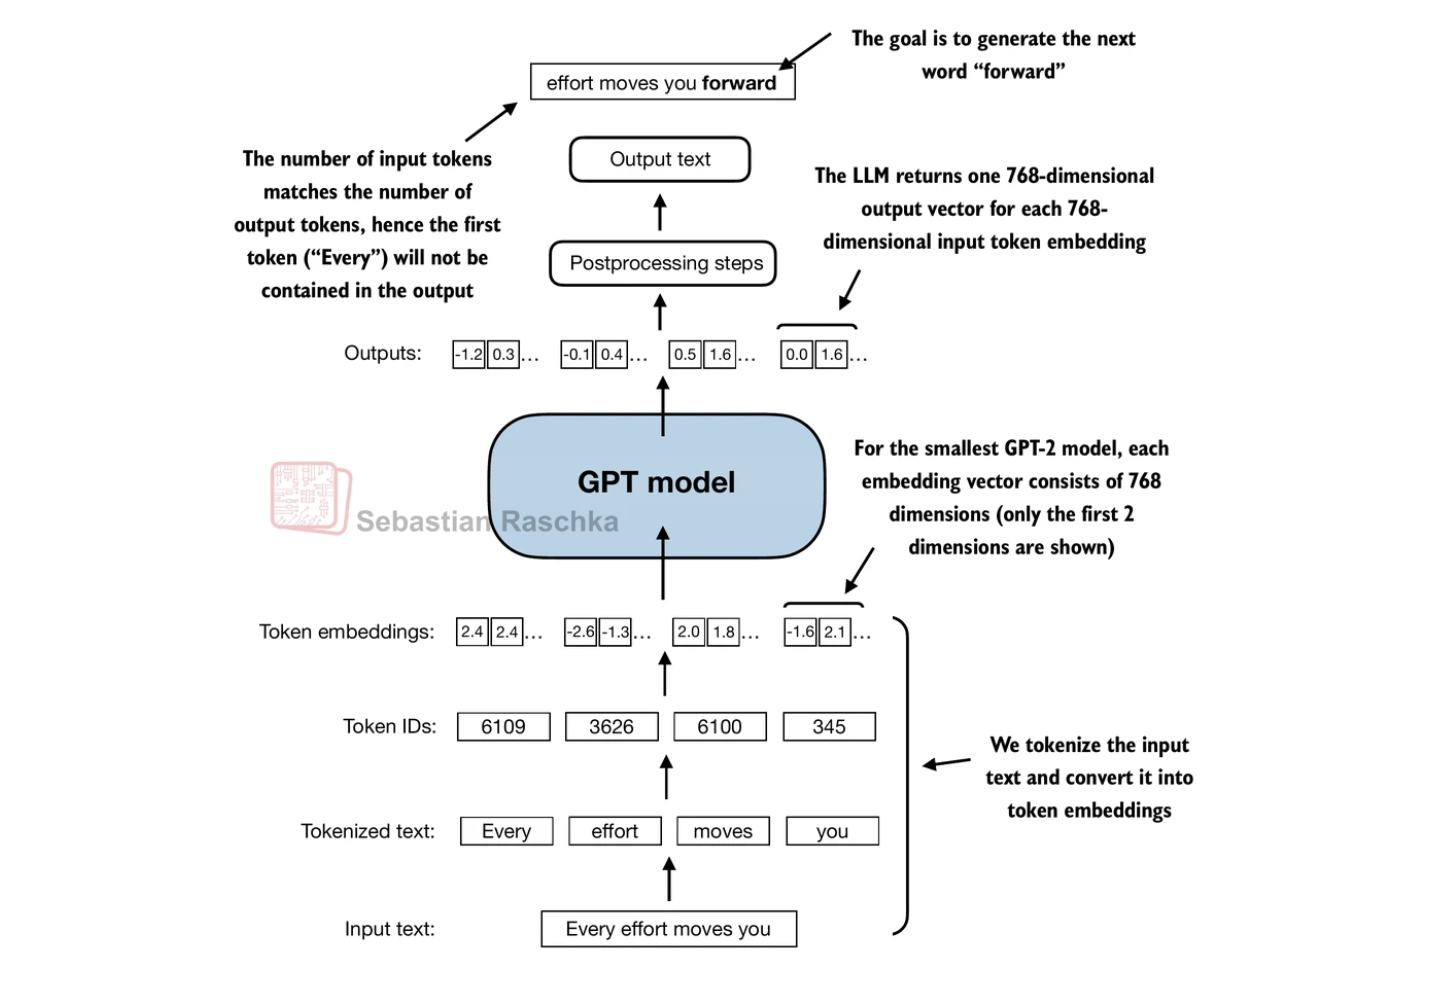

In [5]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

batch = []

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))

batch = torch.stack(batch, dim=0)

print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [6]:
torch.manual_seed(123)

model = DummyGPTModel(GPT_CONFIG_124M)

logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


### 3.2 Normalizing activations with layer normalization

* Stabilizes training and enables faster convergence to effective weights.

* Layer norm is applied both before and after the multi-head attention module within the transformer block. and is also applied before the final output.

In [7]:
torch.manual_seed(123)

# create 2 training examples with 5 dim features each
batch_example = torch.randn(2,5)

# Non-normalized layer
layer = nn.Sequential(nn.Linear(5,6), nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [8]:
batch_example

tensor([[-0.1115,  0.1204, -0.3696, -0.2404, -1.1969],
        [ 0.2093, -0.9724, -0.7550,  0.3239, -0.1085]])

In [9]:
layer

Sequential(
  (0): Linear(in_features=5, out_features=6, bias=True)
  (1): ReLU()
)

In [10]:
out

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)

In [11]:
mean = out.mean(dim=-1, keepdim=True) #dim=-1 applies the calculation across the last dimension.
var = out.var(dim=-1, keepdim=True)

print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


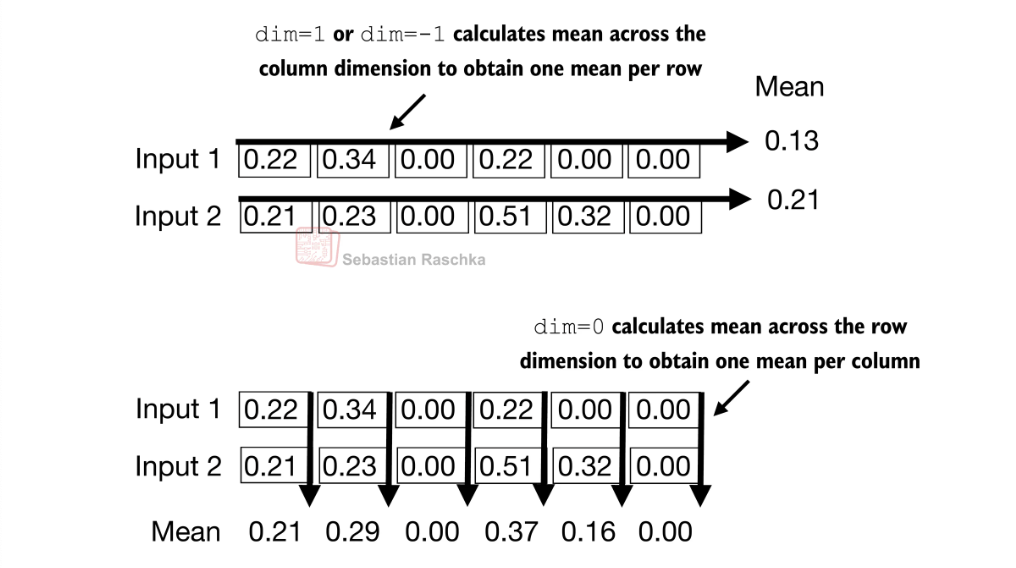

In [12]:
# Normalize the layer output
out_norm = (out - mean) / torch.sqrt(var)
print("Normalized layer outputs:\n", out_norm)

mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)

print("Mean: \n", mean)
print("Variance:\n", var)

Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean: 
 tensor([[-5.9605e-08],
        [ 1.9868e-08]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [13]:
torch.set_printoptions(sci_mode=False)
print("Mean:\n", mean)
print("Variance: \n", var)

Mean:
 tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>)
Variance: 
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


##### Scale and shift
* In addition to normalization, we add scale and shift - trainable parameters that the LLM automatically adjusts during training if it is determined that doing so would improve the model's performance on its training task.
* This allows the model to learn appropriate scaling and shifting that best suit the data it is processing.

In [14]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean= x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x-mean) / torch.sqrt(var + self.eps) # Add small value eps to avoid dividing by 0 variance
        return self.scale * norm_x + self.shift

##### Biased variance
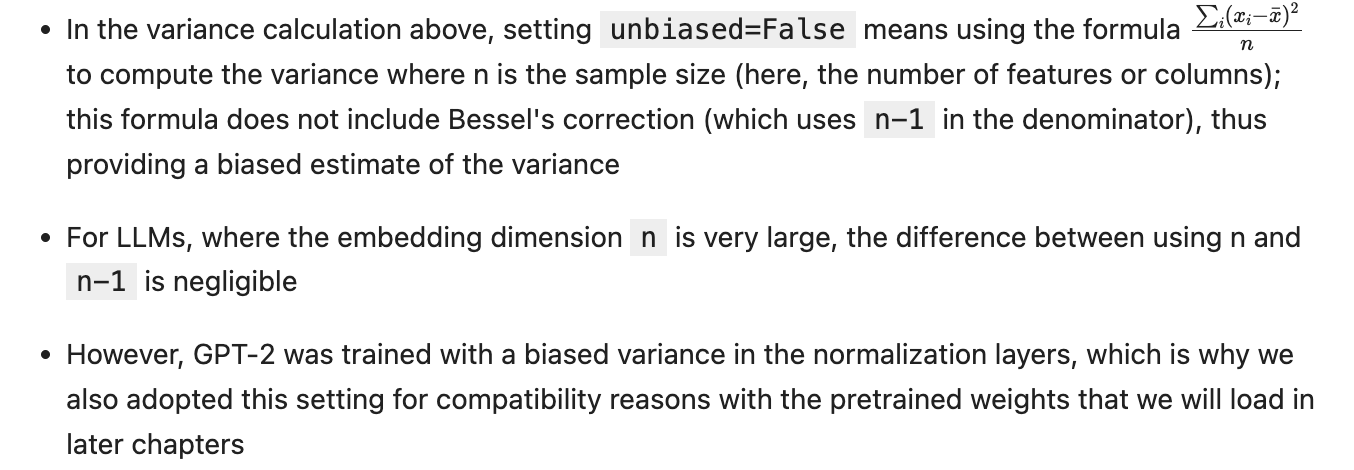

In [15]:
ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)
out_ln

tensor([[ 0.5528,  1.0693, -0.0223,  0.2656, -1.8654],
        [ 0.9087, -1.3767, -0.9564,  1.1304,  0.2940]], grad_fn=<AddBackward0>)

In [16]:
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased = False, keepdim=True)

print("Mean:\n", mean)
print("Var:\n", var)

Mean:
 tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>)
Var:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


### 3.3 Implementing feed-forward network with GELU activation

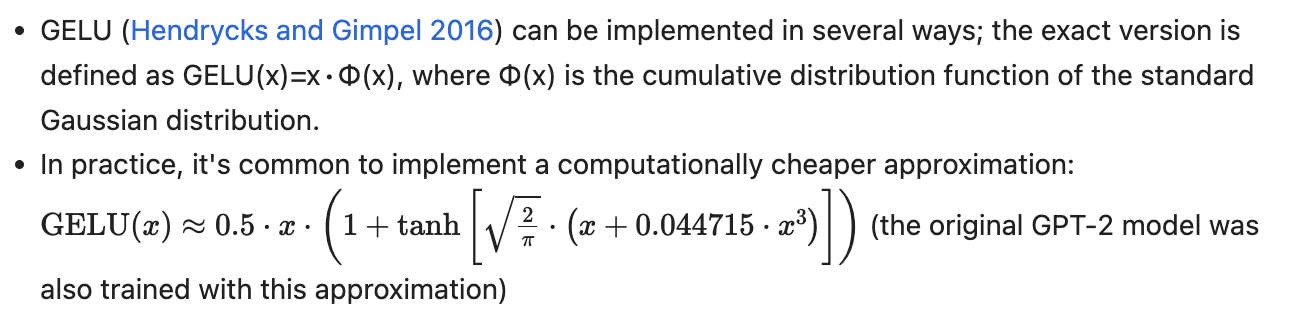

In [17]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x,3))
        ))

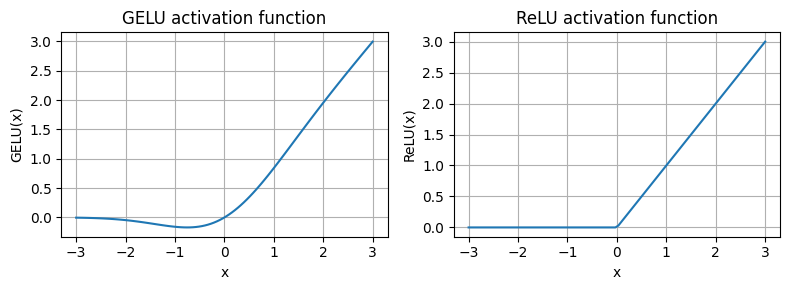

In [20]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

# Some sample data
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x.numpy(), y.detach().numpy())
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

In [22]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"])
        )

    def forward(self,x):
        return self.layers(x)

In [23]:
print(GPT_CONFIG_124M["emb_dim"])

768


In [24]:
ffn = FeedForward(GPT_CONFIG_124M)
ffn

FeedForward(
  (layers): Sequential(
    (0): Linear(in_features=768, out_features=3072, bias=True)
    (1): GELU()
    (2): Linear(in_features=3072, out_features=768, bias=True)
  )
)

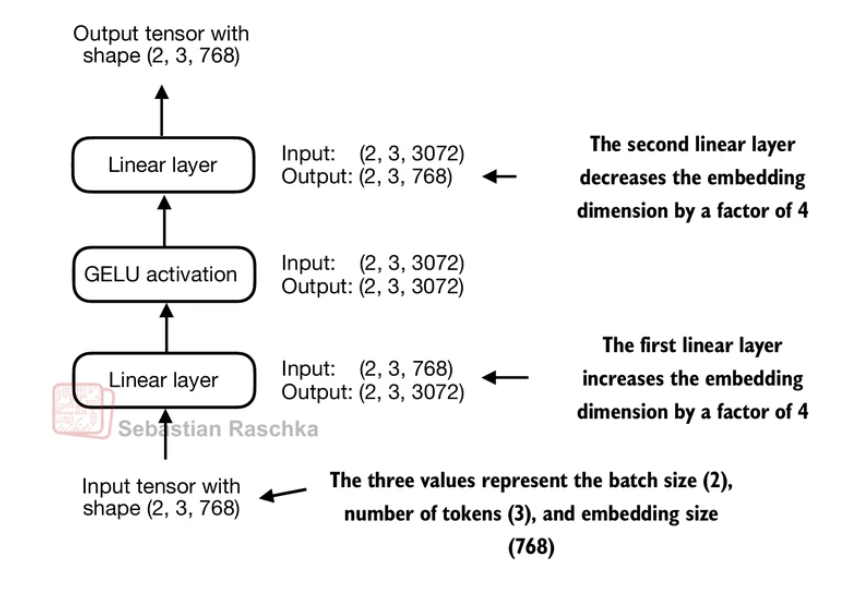

In [25]:
# input shape: [batch_size, num_token, emb_size]
# ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2,3,768)
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


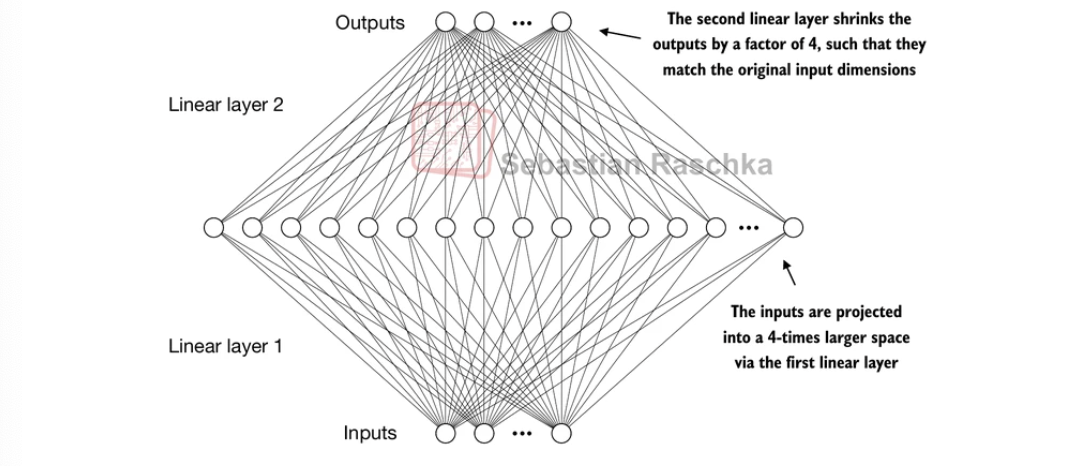

### 3.4 Adding residual/shortcut/skip connections to assemble the transformer block

* Shortcut connections create alternative shorter path for the gradient to flow through the network.
* Achieved by adding the output of one layer to the output of a later layer, usually skipping one or more layers in between.

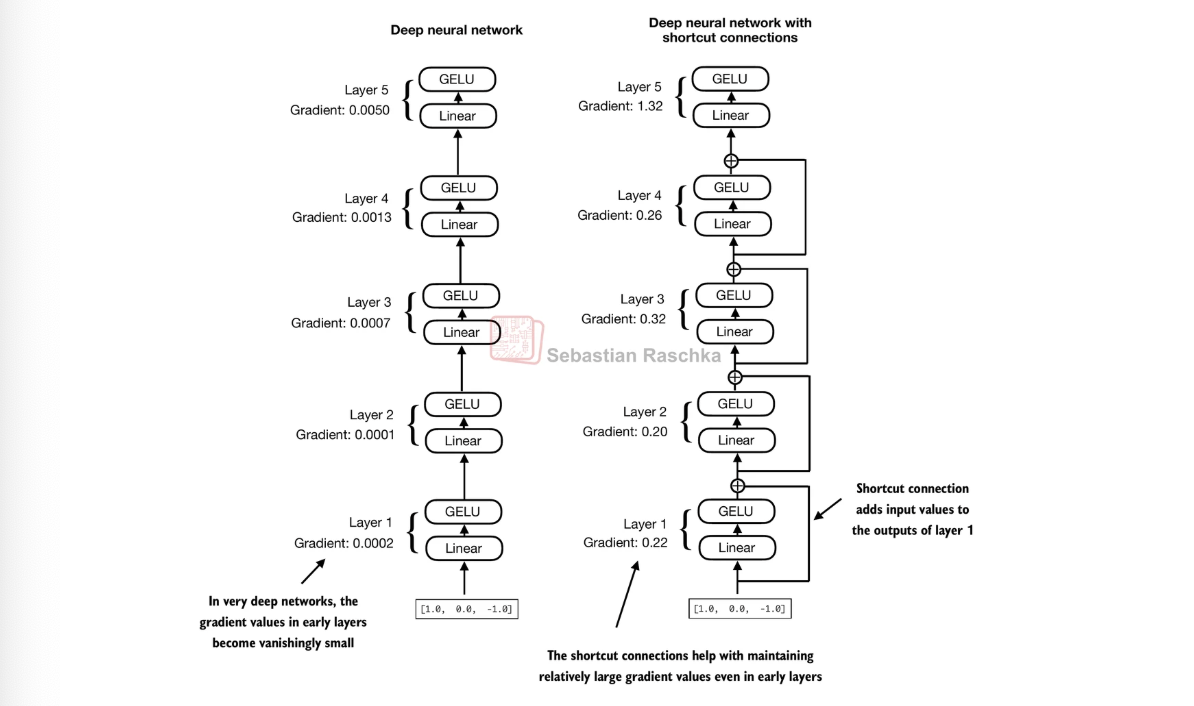

In [29]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
            ])
        
    def forward(self, x):
        for layer in self.layers:
            # Compute output of current layer
            layer_output = layer(x)
            # Check if shortcut can be applied
            if self.use_shortcut and x.shape == layer_output.shape:
                print("\n",layer)
                x = x + layer_output
            else:
                x = layer_output
        return x
    
def print_gradients(model, x):
    # Forward pass
    output = model(x)
    target = torch.tensor([[0.]])

    #Calculate loss based on how close the target and output are
    loss = nn.MSELoss()
    loss = loss(output, target)

    # Backward pass to calculate the gradients
    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            # Print the mean absolute gradients of the weights
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [30]:
layer_sizes = [3, 3, 3, 3, 3, 1]

sample_input = torch.tensor([[1., 0., -1.]])

torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=False
)
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173587836325169
layers.1.0.weight has gradient mean of 0.0001201116101583466
layers.2.0.weight has gradient mean of 0.0007152041071094573
layers.3.0.weight has gradient mean of 0.0013988735154271126
layers.4.0.weight has gradient mean of 0.005049645435065031


In [31]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_input)


 Sequential(
  (0): Linear(in_features=3, out_features=3, bias=True)
  (1): GELU()
)

 Sequential(
  (0): Linear(in_features=3, out_features=3, bias=True)
  (1): GELU()
)

 Sequential(
  (0): Linear(in_features=3, out_features=3, bias=True)
  (1): GELU()
)

 Sequential(
  (0): Linear(in_features=3, out_features=3, bias=True)
  (1): GELU()
)
layers.0.0.weight has gradient mean of 0.22169791162014008
layers.1.0.weight has gradient mean of 0.20694106817245483
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258540630340576


### 3.5 Connecting attention and linear layers in a transformer block

In [33]:
#### Previous code ####

# import tiktoken
# import torch
# import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i+1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)
    
    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]
    

def create_dataloader(txt, batch_size=4, max_length=256, stride=128, shuffle=True, drop_last=True, num_workers=0):
    tokenizer = tiktoken.get_encoding("gpt2")

    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    dataloader = DataLoader(
        dataset, batch_size = batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num_workers
    )

    return dataloader


class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_d_out = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        self.out_proj = nn.Linear(d_out, d_out) 
        self.dropout = nn.Dropout(dropout)
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x) # Linear projection. Shape: (b, num_tokens, d_out) # Matrix multiplication between a weight matrix W and an input vector x occurs over embedding dimension, transforming the features into a new representational space
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a 'num_heads' dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_d_out)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_d_out)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_d_out)
        values = values.view(b, num_tokens, self.num_heads, self.head_d_out)

        # Transpose: (b, num_tokens, num_heads, head_d_out) -> (b, num_heads, num_tokens, head_d_out)
        keys = keys.transpose(1,2)
        queries = queries.transpose(1,2)
        values = values.transpose(1,2)
        
        # Compute scaled dot-product attention (aka batch matrix multiplication aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2,3) # (b, self.num_heads, num_tokens, num_tokens). Batch of matrix multiplication resulting in a score matrix for all tokens within all sequences across all heads.

        # Original mask truncated to the number
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_d_out)
        context_vec = (attn_weights @ values).transpose(1, 2) #((b, self.num_heads, num_tokens, num_tokens) @ (b, self.num_heads, num_tokens, self.head_d_out))T(1,2) = ((b, self.num_heads, num_tokens, self.head_d_out))T(1,2) = (b, num_tokens, self.num_heads, self.head_d_out)

        # Combine head, where self.d_out = self.num_heads * self.head_d_out
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec) #optional projection

        return context_vec